# Network (Swarm) Multi-Agent Pattern — In Depth

## Table of Contents
1. [What Is It?](#what-is-it)
2. [Why Does It Matter?](#why-does-it-matter)
3. [How It Works — Architecture](#how-it-works--architecture)
4. [Comparison With Other Agentic Patterns](#comparison-with-other-agentic-patterns)
5. [Real-World Use Cases](#real-world-use-cases)
6. [Building It From Scratch (LangGraph)](#building-it-from-scratch-langgraph)
7. [Key Takeaways](#key-takeaways)

---

## What Is It?

**Network MAS** (also called **Peer-to-Peer** or **Swarm**) is a multi-agent architecture where there is **no central supervisor or boss**. Instead, specialized agents communicate directly with one another, handing off tasks seamlessly based on what is needed next.

Think of it like a **hospital emergency room**: a Triage Nurse evaluates you, hands you off directly to an X-Ray Technician, who then hands your charts directly to an Orthopedic Surgeon. There is no central "manager" micromanaging every single handoff; the specialists know exactly who to call based on their own expertise.

```mermaid
flowchart LR
    A["📥 User Request"] --> R["🔬 Researcher"]
    R <-->|"handoff"| W["✍️ Writer"]
    W <-->|"handoff"| C["🔍 Critic"]
    C -->|"handoff"| F["🎯 Final Output"]
```

### The Core Idea

In a Supervisor MAS, the flow is always: `Agent A -> Supervisor -> Agent B -> Supervisor -> Agent C`.
In a Network MAS, the flow is direct: `Agent A -> Agent B -> Agent C`.

Each agent is equipped with a specific set of tools for its domain, **plus** a special capability: the ability to **route the conversation to another agent**. In LangGraph, this is typically done by having the agent return a structured routing command or using a specialized "transfer tool".

---

## Why Does It Matter?

### The Problem With Central Supervisors

While Supervisor MAS is great for predictability, it has strict limitations as systems scale:

| Problem | Description |
|---------|-------------|
| **The Bottleneck** | The Supervisor must process every single interaction, slowing down the system and increasing token costs. |
| **Context Overload** | The Supervisor must read the *entire* conversation history of *all* agents to decide what to do next. |
| **Rigid Hierarchies** | Real-world problem solving is often messy and non-linear. Forcing every interaction through a boss can stifle dynamic collaboration. |
| **Single Point of Failure** | If the Supervisor makes a bad routing decision or gets confused, the entire workflow halts. |

### What Network MAS Solves

| Benefit | How |
|---------|-----|
| **Reduced Latency & Cost** | Bypassing the supervisor saves a costly LLM call between every agent interaction. |
| **Dynamic Workflows** | Agents can bounce ideas back and forth rapidly (e.g., Coder and Tester looping until tests pass). |
| **Scalability** | You can add 50 agents to a Swarm, and they only talk to the ones they need to, without overwhelming a central manager. |
| **Natural Conversations** | It mimics how humans actually collaborate in chat rooms or slack channels. |

> [!TIP]
> Network/Swarm architectures are incredibly powerful for open-ended, exploratory tasks where the exact sequence of steps is impossible to predict upfront.

---

## How It Works — Architecture

### The Core Components

#### 1. The Agents (Peers)
Each agent is a self-contained expert with its own system prompt and tools. Crucially, they are aware of their peers and know *when* to transfer control.

#### 2. The Transfer Mechanism
In a Network MAS, agents need a way to say, "I'm done, pass this to Agent X." This is usually implemented in one of two ways:
- **Tool-based Routing:** The agent calls a dummy tool like `transfer_to_writer()`. The system detects this tool call and updates the active agent state.
- **Conditional Edges:** Every agent node ends with a conditional edge that parses the agent's output. If the agent outputs "ROUTER: WRITER", the graph routes to the Writer.

#### 3. Shared State
Like other multi-agent patterns, they share a `messages` list. However, to know who the current "speaker" is, the state typically tracks an `active_agent` variable.

### The Execution Flow

```mermaid
sequenceDiagram
    participant U as User
    participant R as Researcher
    participant W as Writer
    
    U->>R: "Research AI and write a blog"
    R->>R: Uses Web Search Tool
    R->>W: Calls `transfer_to_writer()` with research data
    W->>W: Drafts the blog
    W-->>U: Returns final blog
```

---

## Comparison With Other Agentic Patterns

| Dimension | Supervisor MAS | Network (Swarm) MAS |
|-----------|---------------|---------------------|
| **Control Flow** | Centralized (Hub and Spoke) | Decentralized (Mesh) |
| **Routing Decisions**| Made by 1 Supervisor | Made by individual agents |
| **Token Cost** | Higher (Supervisor runs every turn) | Lower (Direct handoffs) |
| **Debugging** | Easy (Predictable state machine) | Hard (Emergent, non-linear behavior) |
| **Best For** | Strict pipelines with clear stages | Dynamic, conversational collaboration |
| **Risk of Infinite Loops**| Low | High (requires strict safety caps) |

> [!IMPORTANT]
> The biggest challenge of a Network MAS is **chaos**. Without a boss, two agents might endlessly pass a task back and forth ("You do it", "No, you do it"). You **must** implement a hard iteration cap in the graph's state to prevent infinite loops.

---

## Real-World Use Cases

### 1. Complex Software Engineering (Devin-style)
A `Coder` agent writes code. It hands off to a `Tester` agent. If tests fail, the `Tester` hands the exact error logs directly back to the `Coder`. They bounce back and forth rapidly without bothering a manager until the tests pass.

### 2. Specialized Travel Concierge
A user says, "Book me a flight to Tokyo and reserve a sushi restaurant." The `FlightAgent` books the flight, then directly hands off to the `DiningAgent` to handle the restaurant, passing along the arrival times.

### 3. Interactive Debate Panels
Simulating a think-tank where a `TechExpert`, an `Economist`, and an `Ethicist` agent discuss a prompt, handing off to whichever peer they want to challenge next.

### 4. Dynamic Customer Support
A `TriageAgent` talks to the user. Realizes it's a billing issue, hands off to `BillingAgent`. User then asks a technical question; `BillingAgent` seamlessly hands off to `TechSupportAgent`. 

---

## Building It From Scratch (LangGraph)

We will build a **Travel Concierge Swarm** with two peers:
1. **Flight Agent**: Handles flight searches and info.
2. **Hotel Agent**: Handles hotel searches and info.

When the user asks for a complete itinerary, the agents will collaborate directly, handing off to one another until all information is gathered, and then returning the final answer to the user.


In [15]:

### Full Implementation

#### Step 1: Imports and Setup


from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage,SystemMessage
from langchain_core.tools import tool
from typing import Literal
from dotenv import load_dotenv
from typing_extensions import TypedDict
load_dotenv()


True

In [16]:

# We can use the same model for all peers
model = ChatGroq(model='llama-3.1-8b-instant', temperature=0)





In [17]:
#### Step 2: Define Tools and Transfer Mechanisms

# In LangGraph, a very robust way to handle Network MAS is to give agents **"Transfer Tools"**. If an agent calls a transfer tool, we intercept it and route to the new agent.

# ── Domain Tools ──────────────────────────────────────────

@tool
def search_flights(destination: str) -> str:
    """Mock tool to search for flights."""
    return f"Flights to {destination}: Flight AA123 ($450), Flight DL456 ($500)."

@tool
def search_hotels(destination: str) -> str:
    """Mock tool to search for hotels."""
    return f"Hotels in {destination}: Grand Hotel ($200/night), Budget Inn ($80/night)."

# ── Transfer Tools (The Magic of Network MAS) ─────────────

@tool
def transfer_to_flight_agent():
    """Call this tool to transfer the conversation to the Flight Agent."""
    return "Transferred to Flight Agent."

@tool
def transfer_to_hotel_agent():
    """Call this tool to transfer the conversation to the Hotel Agent."""
    return "Transferred to Hotel Agent."



In [18]:

#### Step 3: Define the Agents

# Each agent gets its domain tools AND the transfer tool to hand off to the other.


# Create specific toolsets for each agent
flight_tools = [search_flights, transfer_to_hotel_agent]
hotel_tools = [search_hotels, transfer_to_flight_agent]

# Bind tools to models
flight_model = model.bind_tools(flight_tools)
hotel_model = model.bind_tools(hotel_tools)

def flight_agent_node(state: MessagesState) -> dict:
    """The Flight Expert."""
    messages = state["messages"]
    
    # System prompt injects their persona and instructions on when to transfer
    sys_msg = SystemMessage(content=(
        "You are a Flight Expert. You help users find flights. "
        "If the user also needs hotel information, you MUST use the "
        "`transfer_to_hotel_agent` tool to pass control to the Hotel Expert. "
        "Do NOT try to answer hotel questions yourself."
    ))
    
    response = flight_model.invoke([sys_msg] + messages)
    return {"messages": [response]}

def hotel_agent_node(state: MessagesState) -> dict:
    """The Hotel Expert."""
    messages = state["messages"]
    
    sys_msg = SystemMessage(content=(
        "You are a Hotel Expert. You help users find hotels. "
        "If the user also needs flight information, you MUST use the "
        "`transfer_to_flight_agent` tool to pass control to the Flight Expert. "
        "Do NOT try to answer flight questions yourself."
    ))
    
    response = hotel_model.invoke([sys_msg] + messages)
    return {"messages": [response]}




In [19]:
#### Step 4: The Routing Logic (Conditional Edges)

#We need a router that looks at the last message. If it was a tool call to a transfer tool, we route to that agent. If it's a domain tool (like searching flights), we execute the tool and route back to the *same* agent. If it's just text, we end.


from langgraph.prebuilt import ToolNode

# Standard tool nodes to execute the actual Python functions
flight_tool_node = ToolNode(flight_tools)
hotel_tool_node = ToolNode(hotel_tools)

def flight_router(state: MessagesState) -> str:
    """Routes after the flight agent speaks."""
    last_msg = state["messages"][-1]
    
    if not last_msg.tool_calls:
        # No tool called -> Agent gave final text answer
        return END
        
    # Check WHICH tool was called
    tool_name = last_msg.tool_calls[0]["name"]
    if tool_name == "transfer_to_hotel_agent":
        return "hotel_agent"
    
    # Otherwise, it's a standard tool like search_flights
    return "flight_tools"

def hotel_router(state: MessagesState) -> str:
    """Routes after the hotel agent speaks."""
    last_msg = state["messages"][-1]
    
    if not last_msg.tool_calls:
        return END
        
    tool_name = last_msg.tool_calls[0]["name"]
    if tool_name == "transfer_to_flight_agent":
        return "flight_agent"
    
    return "hotel_tools"



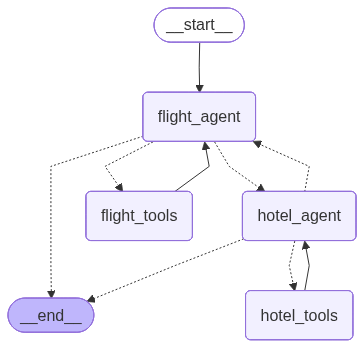

In [22]:

#### Step 5: Build the Graph

# Notice there is NO supervisor node here! Only peers routing to peers.


graph = StateGraph(MessagesState)

# Add Nodes
graph.add_node("flight_agent", flight_agent_node)
graph.add_node("hotel_agent", hotel_agent_node)
graph.add_node("flight_tools", flight_tool_node)
graph.add_node("hotel_tools", hotel_tool_node)

# Add Edges
graph.add_edge(START, "flight_agent") # Default entry point

# Tools always return to the agent that called them
graph.add_edge("flight_tools", "flight_agent")
graph.add_edge("hotel_tools", "hotel_agent")

# Add Routing (Peer-to-Peer Handoffs)
graph.add_conditional_edges(
    "flight_agent", 
    flight_router,
    {"hotel_agent": "hotel_agent", "flight_tools": "flight_tools", END: END}
)

graph.add_conditional_edges(
    "hotel_agent", 
    hotel_router,
    {"flight_agent": "flight_agent", "hotel_tools": "hotel_tools", END: END}
)

workflow = graph.compile()


workflow

In [21]:

#### Step 6: Run It


if __name__ == "__main__":
    # The user asks for both flights and hotels
    request = "I want to go to Paris. Can you find me a flight and a hotel?"
    
    result = workflow.invoke({"messages": [HumanMessage(content=request)]})
    
    print("\n--- Final Answer ---")
    print(result["messages"][-1].content)
    
    print("\n--- Network Handoff Trace ---")
    for msg in result["messages"]:
        if isinstance(msg, AIMessage) and msg.tool_calls:
            tool_name = msg.tool_calls[0]['name']
            if "transfer" in tool_name:
                print(f"🔄 HANDOFF: {tool_name}()")
            else:
                print(f"🛠️ TOOL USED: {tool_name}()")




--- Final Answer ---


--- Network Handoff Trace ---
🔄 HANDOFF: transfer_to_hotel_agent()


## Key Takeaways

> [!IMPORTANT]
> ### Summary of the Network MAS Pattern
> 
> 1. **What**: Decentralized agents that communicate and handoff tasks directly to peers.
> 2. **Why**: Eliminates the bottleneck and token cost of a central supervisor; allows for dynamic, non-linear collaboration.
> 3. **How**: Agents use explicit "Transfer Tools" (or routing commands) to signal the state machine to shift control to a different peer.
> 4. **When**: Use for flexible, conversational workflows (like multi-domain customer support) or tight feedback loops (Coder/Tester).

### Design Principles

| Principle | Details |
|-----------|---------|
| **Clear Transfer Boundaries** | System prompts MUST explicitly explain exactly when and why to use a transfer tool. |
| **Default Entry Points** | Since there is no supervisor to route the first message, you usually route `START` to a default triage agent or the most commonly used agent. |
| **Shared State is King** | Because control bounces around, the `messages` list is the only ground truth. Agents rely entirely on reading the message history to know what the previous peer just did. |

### Common Pitfalls to Avoid

| Pitfall | Solution |
|---------|----------|
| **Infinite Ping-Pong** | Agent A calls Agent B, B calls A, forever. **Fix**: Add an iteration counter to your state and force an `__end__` if it exceeds 10. |
| **Lost Context** | Agents forget what the user originally asked after 5 handoffs. **Fix**: Have agents explicitly summarize their findings before handing off. |
| **"I can do it myself"** | LLMs are inherently helpful and often try to answer questions outside their domain instead of transferring. **Fix**: Use negative prompting ("Do NOT answer hotel questions, YOU MUST transfer"). |

## Complete Implementation Code

In [ ]:
"""
Network (Swarm) Multi-Agent Pattern — LangGraph Implementation
=============================================================

This script implements the Network/Peer-to-Peer pattern where:
1. There is NO central supervisor.
2. A Flight Agent handles flights and can transfer to the Hotel Agent.
3. A Hotel Agent handles hotels and can transfer to the Flight Agent.
4. Agents communicate directly by utilizing "transfer tools" to route the graph.

Architecture:
    START → Flight Agent ↔ Hotel Agent
                  ↓            ↓
                Tools        Tools

Key Concepts:
- Decentralized routing: Agents decide when to hand off control.
- Transfer Tools: Dummy tools used specifically to signal graph routing.
- Context Sharing: The messages list is the shared ground truth.
"""

# ==============================================================================
# Step 1: Imports and Setup
# ==============================================================================

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from typing import Literal
from dotenv import load_dotenv

load_dotenv()

# We use the same model for all peers. Note: For tool calling reliability, 
# a strong model is usually recommended.
model = ChatOpenAI(model='gpt-4o-mini', temperature=0)


# ==============================================================================
# Step 2: Define Tools and Transfer Mechanisms
# ==============================================================================

# ── Domain Tools ──────────────────────────────────────────

@tool
def search_flights(destination: str) -> str:
    """Mock tool to search for flights."""
    return f"Flights to {destination}: Flight AA123 ($450), Flight DL456 ($500)."

@tool
def search_hotels(destination: str) -> str:
    """Mock tool to search for hotels."""
    return f"Hotels in {destination}: Grand Hotel ($200/night), Budget Inn ($80/night)."

# ── Transfer Tools (The Magic of Network MAS) ─────────────

@tool
def transfer_to_flight_agent():
    """Call this tool to transfer the conversation to the Flight Agent."""
    # The return string here is what the LLM sees after calling the tool.
    return "Transferred to Flight Agent."

@tool
def transfer_to_hotel_agent():
    """Call this tool to transfer the conversation to the Hotel Agent."""
    return "Transferred to Hotel Agent."


# ==============================================================================
# Step 3: Define the Agents
# ==============================================================================

# Create specific toolsets for each agent. Notice each gets the ability to 
# transfer to the OTHER agent.
flight_tools = [search_flights, transfer_to_hotel_agent]
hotel_tools = [search_hotels, transfer_to_flight_agent]

# Bind tools to models
flight_model = model.bind_tools(flight_tools)
hotel_model = model.bind_tools(hotel_tools)


def flight_agent_node(state: MessagesState) -> dict:
    """The Flight Expert."""
    messages = state["messages"]
    
    # System prompt injects their persona and instructions on when to transfer
    sys_msg = SystemMessage(content=(
        "You are a Flight Expert. You help users find flights. "
        "If the user also needs hotel information or mentions hotels, you MUST use the "
        "`transfer_to_hotel_agent` tool to pass control to the Hotel Expert. "
        "Do NOT try to answer hotel questions yourself. "
        "If you have answered the flight portion and transferred to the hotel agent, "
        "or if the user only wanted flights, you are done."
    ))
    
    response = flight_model.invoke([sys_msg] + messages)
    
    # We optionally tag the message so we can trace who said what later
    response.name = "flight_agent"
    
    return {"messages": [response]}


def hotel_agent_node(state: MessagesState) -> dict:
    """The Hotel Expert."""
    messages = state["messages"]
    
    sys_msg = SystemMessage(content=(
        "You are a Hotel Expert. You help users find hotels. "
        "If the user also needs flight information or mentions flights, you MUST use the "
        "`transfer_to_flight_agent` tool to pass control to the Flight Expert. "
        "Do NOT try to answer flight questions yourself. "
        "If you have answered the hotel portion and transferred to the flight agent, "
        "or if the user only wanted hotels, you are done."
    ))
    
    response = hotel_model.invoke([sys_msg] + messages)
    response.name = "hotel_agent"
    
    return {"messages": [response]}


# ==============================================================================
# Step 4: The Routing Logic (Conditional Edges)
# ==============================================================================

# Standard tool nodes to execute the actual Python functions
flight_tool_node = ToolNode(flight_tools)
hotel_tool_node = ToolNode(hotel_tools)


def flight_router(state: MessagesState) -> str:
    """Routes after the flight agent speaks."""
    last_msg = state["messages"][-1]
    
    if not last_msg.tool_calls:
        # No tool called -> Agent gave final text answer
        return END
        
    # Check WHICH tool was called
    tool_name = last_msg.tool_calls[0]["name"]
    if tool_name == "transfer_to_hotel_agent":
        return "hotel_agent"
    
    # Otherwise, it's a standard tool like search_flights
    return "flight_tools"


def hotel_router(state: MessagesState) -> str:
    """Routes after the hotel agent speaks."""
    last_msg = state["messages"][-1]
    
    if not last_msg.tool_calls:
        return END
        
    tool_name = last_msg.tool_calls[0]["name"]
    if tool_name == "transfer_to_flight_agent":
        return "flight_agent"
    
    return "hotel_tools"


# ==============================================================================
# Step 5: Build the Graph
# ==============================================================================

graph = StateGraph(MessagesState)

# Add Nodes
graph.add_node("flight_agent", flight_agent_node)
graph.add_node("hotel_agent", hotel_agent_node)
graph.add_node("flight_tools", flight_tool_node)
graph.add_node("hotel_tools", hotel_tool_node)

# Add Edges
# Since we don't have a supervisor, we need a default entry point.
graph.add_edge(START, "flight_agent") 

# Tools always return to the agent that called them
graph.add_edge("flight_tools", "flight_agent")
graph.add_edge("hotel_tools", "hotel_agent")

# Add Routing (Peer-to-Peer Handoffs)
graph.add_conditional_edges(
    "flight_agent", 
    flight_router,
    {"hotel_agent": "hotel_agent", "flight_tools": "flight_tools", END: END}
)

graph.add_conditional_edges(
    "hotel_agent", 
    hotel_router,
    {"flight_agent": "flight_agent", "hotel_tools": "hotel_tools", END: END}
)

workflow = graph.compile()


# ==============================================================================
# Step 6: Run It
# ==============================================================================

if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("🌐 NETWORK (SWARM) MAS — Starting")
    print("=" * 60)

    # The user asks for both flights and hotels
    request = "I want to go to Paris. Can you find me a flight and a hotel?"
    
    print(f"\nUser: {request}")
    
    result = workflow.invoke({"messages": [HumanMessage(content=request)]})
    
    print("\n" + "=" * 60)
    print("🎯 FINAL ANSWER")
    print("=" * 60)
    print(result["messages"][-1].content)
    
    print("\n" + "=" * 60)
    print("🔄 NETWORK HANDOFF TRACE")
    print("=" * 60)
    
    for msg in result["messages"]:
        if isinstance(msg, AIMessage):
            agent_name = getattr(msg, "name", "Unknown Agent")
            
            # If the agent called a tool
            if msg.tool_calls:
                for tc in msg.tool_calls:
                    tool_name = tc['name']
                    if "transfer" in tool_name:
                        print(f"[{agent_name.upper()}] ➡️  HANDOFF: {tool_name}()")
                    else:
                        print(f"[{agent_name.upper()}] 🛠️  TOOL USED: {tool_name}()")
            
            # If the agent spoke text
            elif msg.content:
                print(f"[{agent_name.upper()}] 💬  SPEAKS: {msg.content[:100]}...")
